In [1]:
import librosa
import numpy as np
import librosa.display
from scipy.spatial.distance import euclidean
import matplotlib.pyplot as plt
import os
from mpl_toolkits.mplot3d import Axes3D
from scipy.signal import find_peaks
from scipy.stats import entropy
import pandas as pd
import seaborn as sns

In [2]:
audio_dir = "archive/dev_data/dev_data/slider/train"  

# all_frequencies = []
# all_magnitudes = []

# for audio_file in os.listdir(audio_dir):
#     if audio_file.endswith(".wav"): 
#         audio_path = os.path.join(audio_dir, audio_file)
#         y, sr = librosa.load(audio_path, sr=None)
#         fft = np.fft.fft(y)
#         magnitude = np.abs(fft)
#         frequency = np.fft.fftfreq(len(magnitude), 1/sr)
#         half_range = len(frequency) // 2
#         frequency = frequency[:half_range]
#         magnitude = magnitude[:half_range]
#         all_frequencies.append(frequency)
#         all_magnitudes.append(magnitude)

# plt.figure(figsize=(12, 6))
# for i in range(len(all_frequencies)):
#     plt.plot(all_frequencies[i], all_magnitudes[i])

# plt.title("Magnitude Spectrum of Audio Files")
# plt.xlabel("Frequency(Hz)")
# plt.ylabel("Magnitude")
# plt.show()

In [3]:
# # Filter files with id = 02
# id_02_indices = [index for index, file in enumerate(os.listdir(audio_dir)) if "_id_02_" in file]

# # Plot the magnitude spectrum for the filtered files
# plt.figure(figsize=(12, 6))
# for index in id_02_indices:
#     plt.plot(all_frequencies[index], all_magnitudes[index])

# plt.title("Magnitude Spectrum of Audio Files with ID = 02")
# plt.xlabel("Frequency (Hz)")
# plt.ylabel("Magnitude")
# plt.show()

In [4]:
# # Comparing normal and anomaly audio of the same machine id with id = 02
# # Load normal and anomaly audio files
# normal_audio_path = "archive/dev_data/dev_data/slider/test/normal_id_00_00000090.wav"
# anomaly_audio_path = "archive/dev_data/dev_data/slider/test/anomaly_id_00_00000090.wav"
# # Load the audio files
# y_normal, sr_normal = librosa.load(normal_audio_path, sr=None)
# y_anomaly, sr_anomaly = librosa.load(anomaly_audio_path, sr=None)
# # Calculate the Mel spectrograms
# S_normal = librosa.feature.melspectrogram(y=y_normal, sr=sr_normal, n_mels=128, fmax=8000)
# S_anomaly = librosa.feature.melspectrogram(y=y_anomaly, sr=sr_anomaly, n_mels=128, fmax=8000)
# # Convert to decibels
# S_dB_normal = librosa.power_to_db(S_normal, ref=np.max)
# S_dB_anomaly = librosa.power_to_db(S_anomaly, ref=np.max)
# # Plot the Mel spectrograms
# plt.figure(figsize=(14, 6))
# # Plot the normal audio spectrogram
# plt.subplot(1, 2, 1)
# librosa.display.specshow(S_dB_normal, sr=sr_normal, x_axis='time', y_axis='mel', fmax=8000)
# plt.colorbar(format='%+2.0f dB')
# plt.title('Spectrogram - Normal')
# # Plot the anomaly audio spectrogram
# plt.subplot(1, 2, 2)
# librosa.display.specshow(S_dB_anomaly, sr=sr_anomaly, x_axis='time', y_axis='mel', fmax=8000)
# plt.colorbar(format='%+2.0f dB')
# plt.title('Spectrogram - Anomaly')
# plt.tight_layout()
# plt.show()

In [5]:
# fig = plt.figure(figsize=(20, 12))
# normal_audio_path = "archive/dev_data/dev_data/slider/test/normal_id_04_00000070.wav"
# anomaly_audio_path = "archive/dev_data/dev_data/slider/test/anomaly_id_04_00000070.wav"
# # Define T and F for the 3D spectrogram
# T, F = np.meshgrid(
#     np.linspace(0, len(y_normal) / sr_normal, S_dB_normal.shape[1]),
#     np.linspace(0, sr_normal / 2, S_dB_normal.shape[0])
# )
# ax2 = fig.add_subplot(121, projection='3d')
# ax2.plot_surface(T, F, S_dB_normal, cmap='plasma')
# ax2.set_title('3D Spectrogram - Normal')
# ax2.set_xlabel('Time (s)')
# ax2.set_ylabel('Frequency (Hz)')
# ax2.set_zlabel('Amplitude (dB)')
# ax2.grid(False) 
# ax2.set_xticks([0, 0.01, 0.02, 0.03]) 
# ax2.set_yticks([0, 4000, 8000]) 

# ax1 = fig.add_subplot(122, projection='3d')
# ax1.plot_surface(T, F, S_dB_anomaly, cmap='viridis')
# ax1.set_title('3D Spectrogram - Anomaly')
# ax1.set_xlabel('Time (s)')
# ax1.set_ylabel('Frequency (Hz)')
# ax1.set_zlabel('Amplitude (dB)')
# ax1.grid(False)  
# ax1.set_xticks([0, 0.01, 0.02, 0.03])  
# ax1.set_yticks([0, 4000, 8000])  

# plt.subplots_adjust(wspace=0.5)
# plt.tight_layout()
# plt.show()



plot wave form di anomalo e di uno normal 
time:
    Peak-to-Peak Amplitude
    Root Mean Square (RMS)
    Standard Deviation / Variance
    area sotto il segnale 
    peak pos
    peak neg
    peak to peak
    num peaks
    distance from mean signal per id
freq:
    Signal-to-Noise Ratio (SNR): Low SNR means more noise.
    Spectral Entropy: Measures signal randomness (higher entropy → more noise).
pip install librosa==0.10.1 numba==0.56.4 llvmlite==0.39.1


In [6]:
# plt.figure(figsize=(14, 6))
# time = np.linspace(0, len(y_normal) / sr_normal, num=len(y_normal))
# plt.plot(time, y_anomaly, label="Anomaly", alpha=0.5)
# plt.plot(time, y_normal, label="Normal", alpha=0.5)
# plt.title("Waveform of Normal and Anomaly Audio")
# plt.xlabel("Time (s)")
# plt.ylabel("Amplitude")
# plt.legend()
# plt.show()

In [7]:
from collections import defaultdict

# Dictionary to store means for each machine ID
machine_means = defaultdict(list)

# Iterate through audio files in the train set
for audio_file in os.listdir(audio_dir):
    if audio_file.endswith(".wav"):
        # Extract machine ID from the file name (assuming the format includes "_id_XX_")
        machine_id = audio_file.split("_id_")[1].split("_")[0]
        
        # Load the audio file
        audio_path = os.path.join(audio_dir, audio_file)
        y, sr = librosa.load(audio_path, sr=None)
        
        # Compute the mean of the audio signal
        mean_value = np.mean(y)
        
        # Append the mean to the corresponding machine ID
        machine_means[machine_id].append(mean_value)

# Compute the overall mean for each machine ID
machine_means = {machine_id: np.mean(means) for machine_id, means in machine_means.items()}

print(machine_means)

# Dictionary to store FFT means for each machine ID
machine_fft_means = defaultdict(list)

# Iterate through audio files in the train set
for audio_file in os.listdir(audio_dir):
    if audio_file.endswith(".wav"):
        # Extract machine ID from the file name
        machine_id = audio_file.split("_id_")[1].split("_")[0]
        
        # Load the audio file
        audio_path = os.path.join(audio_dir, audio_file)
        y, sr = librosa.load(audio_path, sr=None)
        
        # Compute the FFT of the audio signal
        fft = np.fft.fft(y)
        magnitude = np.abs(fft)
        
        # Compute the mean of the FFT magnitude
        fft_mean = np.mean(magnitude)
        
        # Append the FFT mean to the corresponding machine ID
        machine_fft_means[machine_id].append(fft_mean)

# Compute the overall FFT mean for each machine ID
machine_fft_means = {machine_id: np.mean(means) for machine_id, means in machine_fft_means.items()}

print(machine_fft_means)

{'00': np.float32(-3.5388723e-07), '02': np.float32(-3.2580922e-07), '04': np.float32(-3.3895697e-07)}
{'00': np.float32(1.8713626), '02': np.float32(1.9488124), '04': np.float32(2.4619277)}


232.93907
Number of spectral peaks: 0


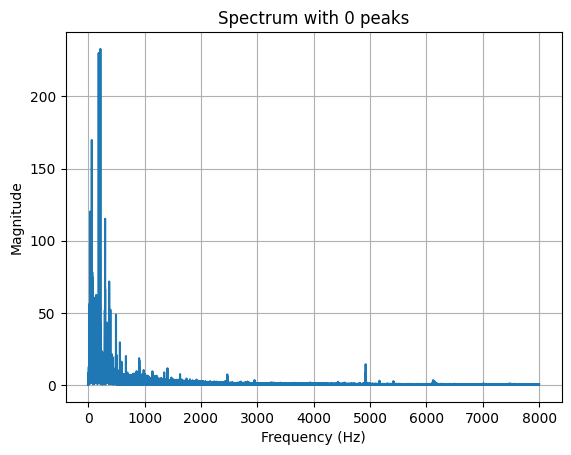

In [8]:
# Function to compute the number of peaks in the FFT magnitude spectrum
def count_peaks_in_fft(audio_path):
    y, sr = librosa.load(audio_path, sr=None)  # Load the audio file
    fft_magnitude = np.abs(np.fft.rfft(y))     # Compute the one-sided FFT magnitude
    peaks, _ = find_peaks(fft_magnitude, height=250) # Try several values 125 150 175 200 250 etc
    print(np.max(fft_magnitude)) # Find significant peaks
    return len(peaks), fft_magnitude, sr       # Return number of peaks, spectrum, and sample rate

# Example on a single file
audio_path = "archive/dev_data/dev_data/slider/test/anomaly_id_02_00000080.wav"         
n_peaks, fft_mag, sr = count_peaks_in_fft(audio_path)
print(f"Number of spectral peaks: {n_peaks}")

# Plot the FFT magnitude spectrum
plt.plot(np.linspace(0, sr/2, len(fft_mag)), fft_mag)
plt.title(f"Spectrum with {n_peaks} peaks")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid()
plt.show()


     Machine ID Sound Type  Number of Peaks  Cluster
0            00     normal                1  anomaly
1            00     normal                0  anomaly
2            00     normal                0  anomaly
3            00     normal                1  anomaly
4            00     normal                0  anomaly
...         ...        ...              ...      ...
3466         04     normal                0  anomaly
3467         04     normal                1  anomaly
3468         04     normal                1  anomaly
3469         04     normal                0  anomaly
3470         04     normal                0  anomaly

[3471 rows x 4 columns]


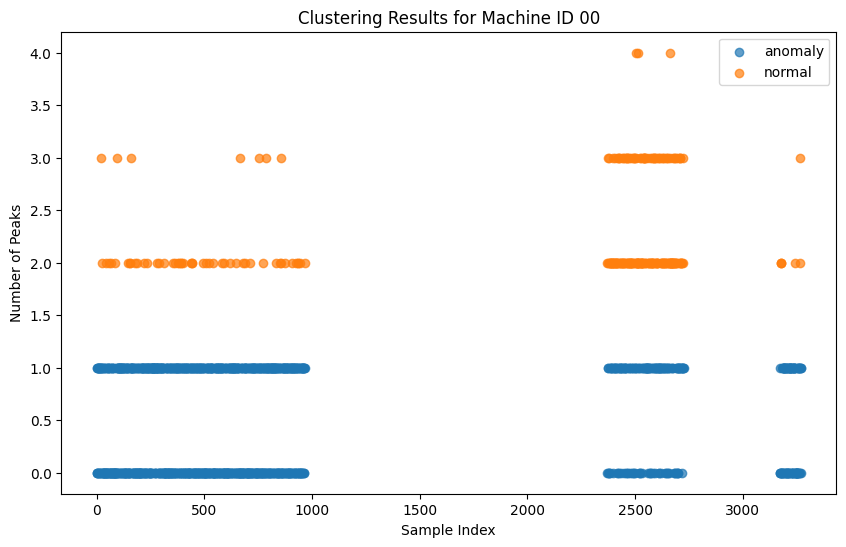

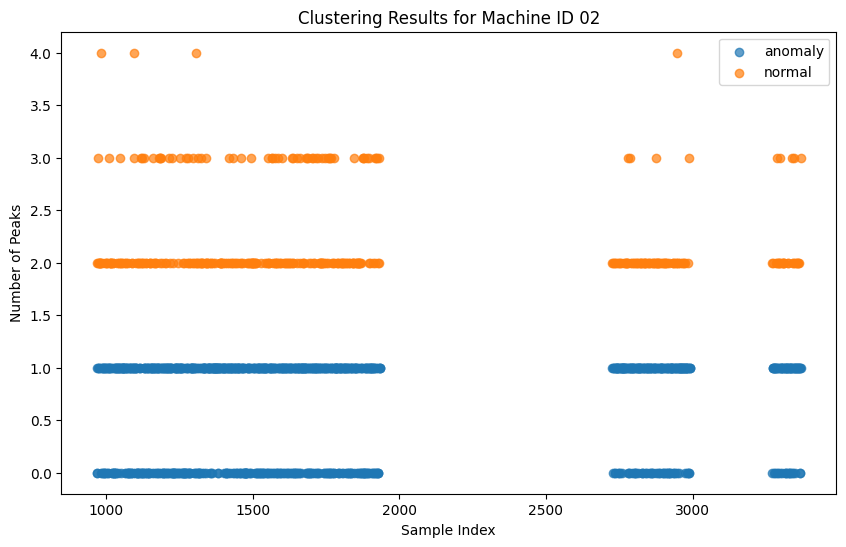

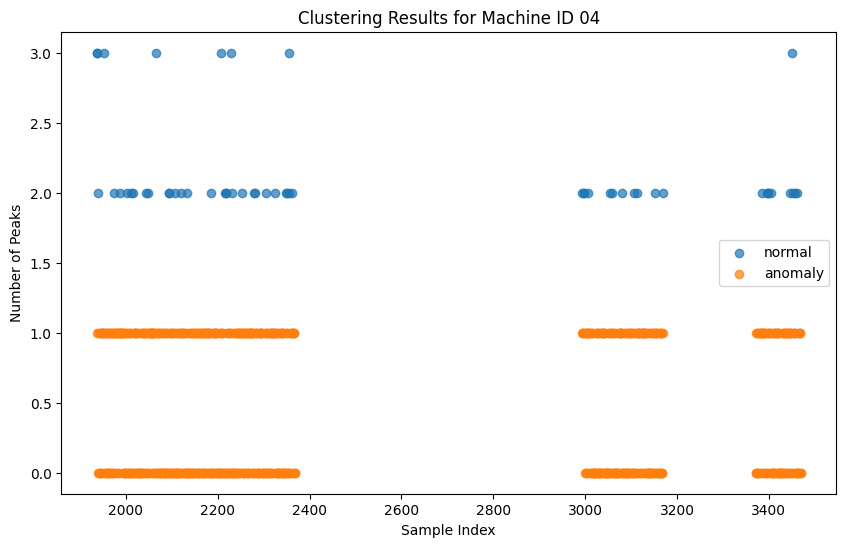

In [9]:
from sklearn.cluster import KMeans
import numpy as np
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

# Directories containing train and test audio files
train_dir = "archive/dev_data/dev_data/slider/train"
test_dir = "archive/dev_data/dev_data/slider/test"

# Combine train and test directories
audio_dirs = [train_dir, test_dir]

# Compute the number of peaks for each sound in both train and test sets
all_features = []
for audio_dir in audio_dirs:
    for audio_file in os.listdir(audio_dir):
        if audio_file.endswith(".wav"):
            machine_id = audio_file.split("_id_")[1].split("_")[0]
            audio_path = os.path.join(audio_dir, audio_file)
            y, sr = librosa.load(audio_path, sr=None)
            fft_magnitude = np.abs(np.fft.rfft(y))
            peaks, _ = find_peaks(fft_magnitude, height=250)
            sound_type = "anomaly" if audio_file.split("_")[0] == "anomaly" else "normal"
            all_features.append({"Machine ID": machine_id, "Sound Type": sound_type, "Number of Peaks": len(peaks)})

# Create a DataFrame for the combined features
all_features_df = pd.DataFrame(all_features)

# Perform clustering
kmeans = KMeans(n_clusters=2, random_state=42)
all_features_df["Cluster"] = kmeans.fit_predict(all_features_df[["Number of Peaks"]])

# Map cluster labels to anomaly/normal
cluster_labels = {0: "anomaly", 1: "normal"}
all_features_df["Cluster"] = all_features_df["Cluster"].map(cluster_labels)
print(all_features_df)

# Plot for each machine ID
unique_machine_ids = all_features_df["Machine ID"].unique()
for machine_id in unique_machine_ids:
    subset = all_features_df[all_features_df["Machine ID"] == machine_id]
    plt.figure(figsize=(10, 6))
    for sound_type in subset["Cluster"].unique():
        data = subset[subset["Cluster"] == sound_type]
        plt.scatter(data.index, data["Number of Peaks"], label=sound_type, alpha=0.7)
    plt.title(f"Clustering Results for Machine ID {machine_id}")
    plt.xlabel("Sample Index")
    plt.ylabel("Number of Peaks")
    plt.legend()
    plt.show()

In [10]:
from sklearn.metrics import silhouette_score

# Extract the feature used for clustering (Number of Peaks)
X = all_features_df[["Number of Peaks"]]

# Compute the silhouette score
silhouette = silhouette_score(X, kmeans.labels_)
print(f"Silhouette Score: {silhouette}")

Silhouette Score: 0.711414190688947


In [11]:
# Count the number of anomaly and normal sounds in the train set based on file names
train_anomaly_count = sum(1 for audio_file in os.listdir(train_dir) if audio_file.startswith("anomaly"))
train_normal_count = sum(1 for audio_file in os.listdir(train_dir) if audio_file.startswith("normal"))
print("Train Set Counts:")
print(f"Anomaly: {train_anomaly_count}, Normal: {train_normal_count}")

# Count the number of anomaly and normal sounds in the test set based on file names
test_anomaly_count = sum(1 for audio_file in os.listdir(test_dir) if audio_file.startswith("anomaly"))
test_normal_count = sum(1 for audio_file in os.listdir(test_dir) if audio_file.startswith("normal"))
print("\nTest Set Counts:")
print(f"Anomaly: {test_anomaly_count}, Normal: {test_normal_count}")

Train Set Counts:
Anomaly: 0, Normal: 2370

Test Set Counts:
Anomaly: 801, Normal: 300


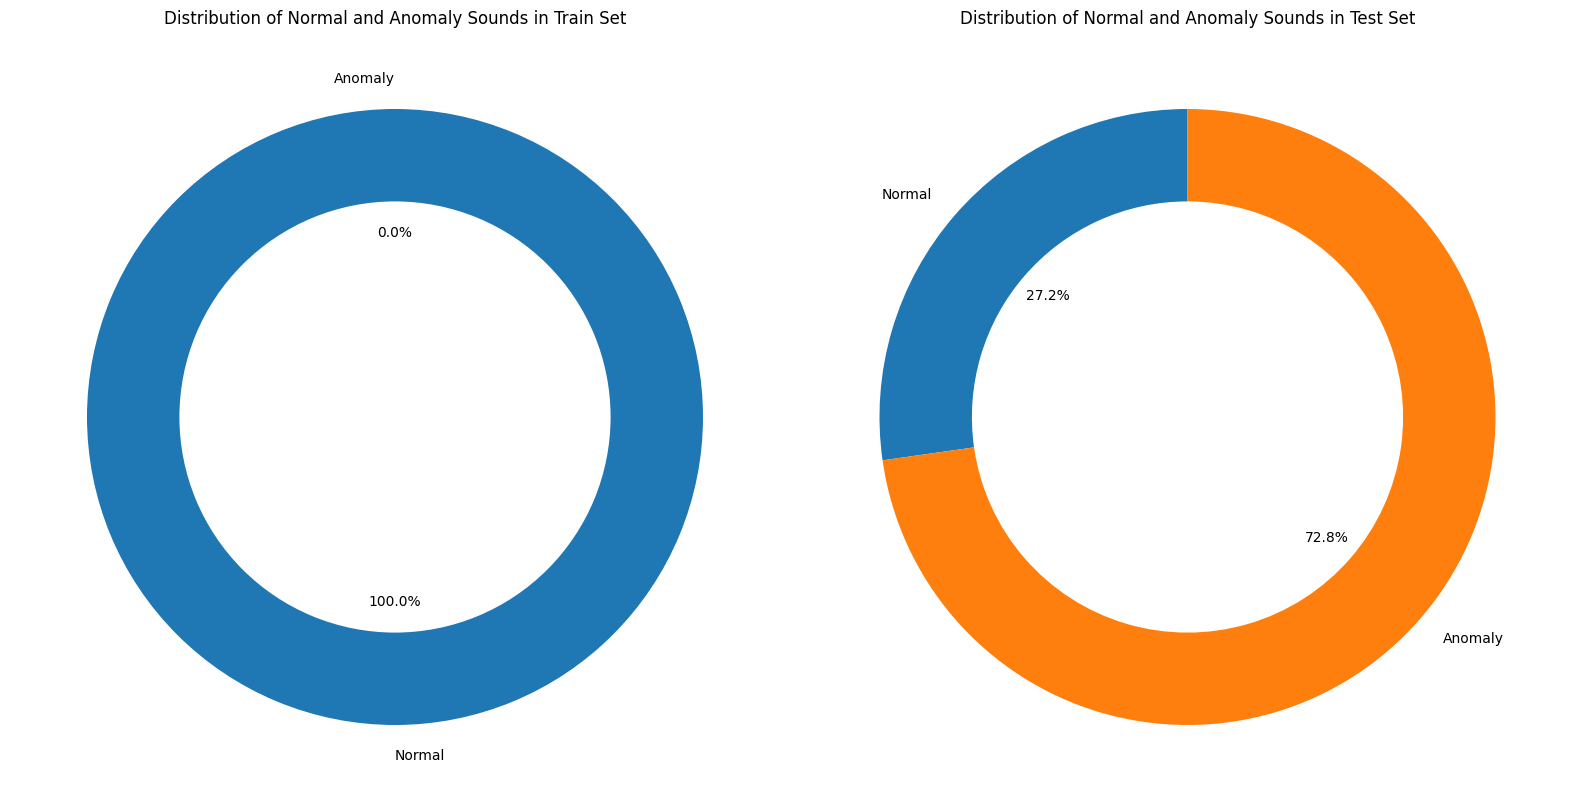

In [12]:
# Data for the donut charts
train_labels = ['Normal', 'Anomaly']
train_sizes = [train_normal_count, train_anomaly_count]

test_labels = ['Normal', 'Anomaly']
test_sizes = [test_normal_count, test_anomaly_count]

# Plot the donut charts
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Train dataset donut chart
axes[0].pie(train_sizes, labels=train_labels, autopct='%1.1f%%', startangle=90, wedgeprops=dict(width=0.3))
axes[0].set_title('Distribution of Normal and Anomaly Sounds in Train Set')

# Test dataset donut chart
axes[1].pie(test_sizes, labels=test_labels, autopct='%1.1f%%', startangle=90, wedgeprops=dict(width=0.3))
axes[1].set_title('Distribution of Normal and Anomaly Sounds in Test Set')

plt.tight_layout()
plt.show()

In [13]:
machine_mfcc_means = defaultdict(list)

# Iterate through audio files in the train set
for audio_file in os.listdir(audio_dir):
    if audio_file.endswith(".wav"):
        # Extract machine ID from the file name
        machine_id = audio_file.split("_id_")[1].split("_")[0]
        
        # Load the audio file
        audio_path = os.path.join(audio_dir, audio_file)
        y, sr = librosa.load(audio_path, sr=None)
        
        # Compute the FFT of the audio signal
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=25)
        magnitude = np.abs(mfcc)
        
        # Compute the mean of the FFT magnitude
        mfcc_mean = np.mean(magnitude)
        
        # Append the FFT mean to the corresponding machine ID
        machine_mfcc_means[machine_id].append(mfcc_mean)

# Compute the overall FFT mean for each machine ID
machine_mfcc_means = {machine_id: np.mean(means) for machine_id, means in machine_mfcc_means.items()}


In [14]:
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import euclidean

audio_dir = "archive/dev_data/dev_data/slider/train"  
peak_threshold = 0.01
features = []
for audio_file in os.listdir(audio_dir):
    if audio_file.endswith(".wav"):
        machine_id = audio_file.split("_id_")[1].split("_")[0] 
        audio_path = os.path.join(audio_dir, audio_file)
        y, sr = librosa.load(audio_path, sr=None)
        peak_to_peak_amplitude = np.ptp(y)
        rms = np.sqrt(np.mean(y**2))
        std_dev = np.std(y)
        area_under_signal = np.sum(np.abs(y)) / sr
        peak_positive = np.max(y)
        peak_negative = np.min(y)
        fft_magnitude = np.abs(np.fft.rfft(y))  
        num_peaks, _ = find_peaks(fft_magnitude, height=250)  # Adjusted height 
        distance_from_mean = np.mean(np.abs(y - machine_means[machine_id]))
        distance_from_mean_fft = np.mean(np.abs(fft_magnitude - machine_fft_means[machine_id]))
        distance_from_mean_mfcc = np.mean(np.abs(mfcc - machine_mfcc_means[machine_id]))
        fft = np.fft.fft(y)
        magnitude = np.abs(fft)
        snr = np.mean(magnitude) / np.std(magnitude)
        spectral_entropy = entropy(magnitude / np.sum(magnitude))
        zcr = np.mean(librosa.feature.zero_crossing_rate(y))
        sc = np.mean(librosa.feature.spectral_centroid(y=y,sr=sr))
        sb = np.mean(librosa.feature.spectral_bandwidth(y=y,sr=sr))
        sco = np.mean(librosa.feature.spectral_contrast(y=y,sr=sr))
        features.append({
            "Peak-to-Peak Amplitude": peak_to_peak_amplitude,
            "RMS": rms,
            "Standard Deviation": std_dev,
            "Area Under Signal": area_under_signal,
            "Peak Positive": peak_positive,
            "Peak Negative": peak_negative,
            "Number of Peaks": len(num_peaks),
            "Distance from Mean": distance_from_mean,
            "SNR": snr,
            "Spectral Entropy": spectral_entropy,
            "Spectral Centroid": sc,
            "Spectral Bandwidth": sb,
            "Spectral Contrast": sco,
            "Zero Crossing Rate": zcr,
            "Distance from Mean ftt": distance_from_mean_fft,
            "distance_from_mean_mfcc": distance_from_mean_mfcc,
        })

features_df = pd.DataFrame(features)
print(features_df)
scaler = StandardScaler()
normalized_features = scaler.fit_transform(features_df)
normalized_features_df = pd.DataFrame(normalized_features, columns=features_df.columns)
print(normalized_features_df)

      Peak-to-Peak Amplitude       RMS  Standard Deviation  Area Under Signal  \
0                   0.108887  0.010265            0.010265           0.081804   
1                   0.103485  0.010483            0.010483           0.083287   
2                   0.099762  0.010467            0.010467           0.083141   
3                   0.087036  0.010480            0.010480           0.083738   
4                   0.081940  0.010205            0.010205           0.081638   
...                      ...       ...                 ...                ...   
2365                0.136322  0.011126            0.011126           0.086639   
2366                0.122467  0.011288            0.011288           0.089523   
2367                0.110107  0.011058            0.011058           0.087476   
2368                0.107452  0.011048            0.011048           0.087681   
2369                0.113464  0.011199            0.011199           0.087901   

      Peak Positive  Peak N

In [15]:
normalized_features_df.to_csv("train_set.csv", index=False)

In [16]:
from sklearn.ensemble import IsolationForest

# Initialize the Isolation Forest model
iso_forest = IsolationForest(contamination=0.1, random_state=42, n_estimators=200)

# Fit the model on the features NON NORMALIZED
iso_forest.fit(features_df)

# Obtain anomaly scores
anomaly_scores = iso_forest.decision_function(features_df)

# Print the anomaly scores
print(anomaly_scores)

[ 0.05851737  0.06253952 -0.03716004 ...  0.08208231  0.07329817
  0.01534063]


In [18]:
from sklearn.metrics import roc_auc_score

# Extract features for the test set
test_features = []
for audio_file in os.listdir(test_dir):
    if audio_file.endswith(".wav"):
        machine_id = audio_file.split("_id_")[1].split("_")[0]
        audio_path = os.path.join(test_dir, audio_file)
        y, sr = librosa.load(audio_path, sr=None)
        peak_to_peak_amplitude = np.ptp(y)
        rms = np.sqrt(np.mean(y**2))
        std_dev = np.std(y)
        area_under_signal = np.sum(np.abs(y)) / sr
        peak_positive = np.max(y)
        peak_negative = np.min(y)
        fft_magnitude = np.abs(np.fft.rfft(y))
        num_peaks, _ = find_peaks(fft_magnitude, height=250)
        distance_from_mean = np.mean(np.abs(y - machine_means[machine_id]))
        distance_from_mean_fft = np.mean(np.abs(fft_magnitude - machine_fft_means[machine_id]))
        distance_from_mean_mfcc = np.mean(np.abs(mfcc - machine_mfcc_means[machine_id]))
        snr = np.mean(fft_magnitude) / np.std(fft_magnitude)
        spectral_entropy = entropy(fft_magnitude / np.sum(fft_magnitude))
        zcr = np.mean(librosa.feature.zero_crossing_rate(y))
        sc = np.mean(librosa.feature.spectral_centroid(y=y,sr=sr))
        sb = np.mean(librosa.feature.spectral_bandwidth(y=y,sr=sr))
        sco = np.mean(librosa.feature.spectral_contrast(y=y,sr=sr))
        test_features.append({
            "Peak-to-Peak Amplitude": peak_to_peak_amplitude,
            "RMS": rms,
            "Standard Deviation": std_dev,
            "Area Under Signal": area_under_signal,
            "Peak Positive": peak_positive,
            "Peak Negative": peak_negative,
            "Number of Peaks": len(num_peaks),
            "Distance from Mean": distance_from_mean,
            "SNR": snr,
            "Spectral Entropy": spectral_entropy,
            "Spectral Centroid": sc,
            "Spectral Bandwidth": sb,
            "Spectral Contrast": sco,
            "Zero Crossing Rate": zcr,
            "Distance from Mean ftt": distance_from_mean_fft,
            "distance_from_mean_mfcc": distance_from_mean_mfcc,
        })

test_features_df = pd.DataFrame(test_features)
print(test_features_df)

# Normalize test features using training set mean and std
test_features_df_normalized = scaler.transform(test_features_df)

# Extract ground truth labels (assuming 1 for normal and -1 for anomaly)
y_test = [1 if audio_file.startswith("normal") else -1 for audio_file in os.listdir(test_dir) if audio_file.endswith(".wav")]

# Predict anomaly scores using the Isolation Forest model
test_anomaly_scores = iso_forest.decision_function(test_features_df)

# Evaluate using Area Under the Curve (AUC)
auc_score = roc_auc_score(y_test, test_anomaly_scores)
print(f"Area Under Curve (AUC) Score: {auc_score}")

      Peak-to-Peak Amplitude       RMS  Standard Deviation  Area Under Signal  \
0                   0.158447  0.015101            0.015101           0.117589   
1                   0.138092  0.013135            0.013135           0.103399   
2                   0.161224  0.014332            0.014332           0.111220   
3                   0.148132  0.013034            0.013034           0.099206   
4                   0.142639  0.013042            0.013042           0.102642   
...                      ...       ...                 ...                ...   
1096                0.114532  0.011000            0.011000           0.087516   
1097                0.100983  0.011199            0.011199           0.088904   
1098                0.104858  0.011116            0.011116           0.088667   
1099                0.104340  0.011002            0.011002           0.087574   
1100                0.107697  0.011164            0.011164           0.088713   

      Peak Positive  Peak N

In [19]:
test_normalized_features_df = pd.DataFrame(test_features_df_normalized, columns=features_df.columns)
test_normalized_features_df.to_csv("test_set.csv", index=False)

In [ ]:
from sklearn.svm import OneClassSVM

# Initialize the One-Class SVM model
oc_svm = OneClassSVM(kernel='rbf', gamma=0.1, nu=0.1)

# Fit the model on the normalized training features
oc_svm.fit(normalized_features_df)

# Predict anomaly scores for the test set
test_oc_svm_scores = oc_svm.decision_function(test_features_df_normalized)

# Extract ground truth labels (assuming 1 for normal and -1 for anomaly)
y_test = [1 if audio_file.startswith("normal") else -1 for audio_file in os.listdir(test_dir) if audio_file.endswith(".wav")]

# Evaluate using Area Under the Curve (AUC)
auc_score = roc_auc_score(y_test, test_oc_svm_scores)
print(f"Area Under Curve (AUC) Score: {auc_score}")

Area Under Curve (AUC) Score: 0.8780690803162714


c:\Users\user\Desktop\data science\EURECOM\2 SEMESTRE\AML\AML-Challenges\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but OneClassSVM was fitted with feature names
  warnings.warn(


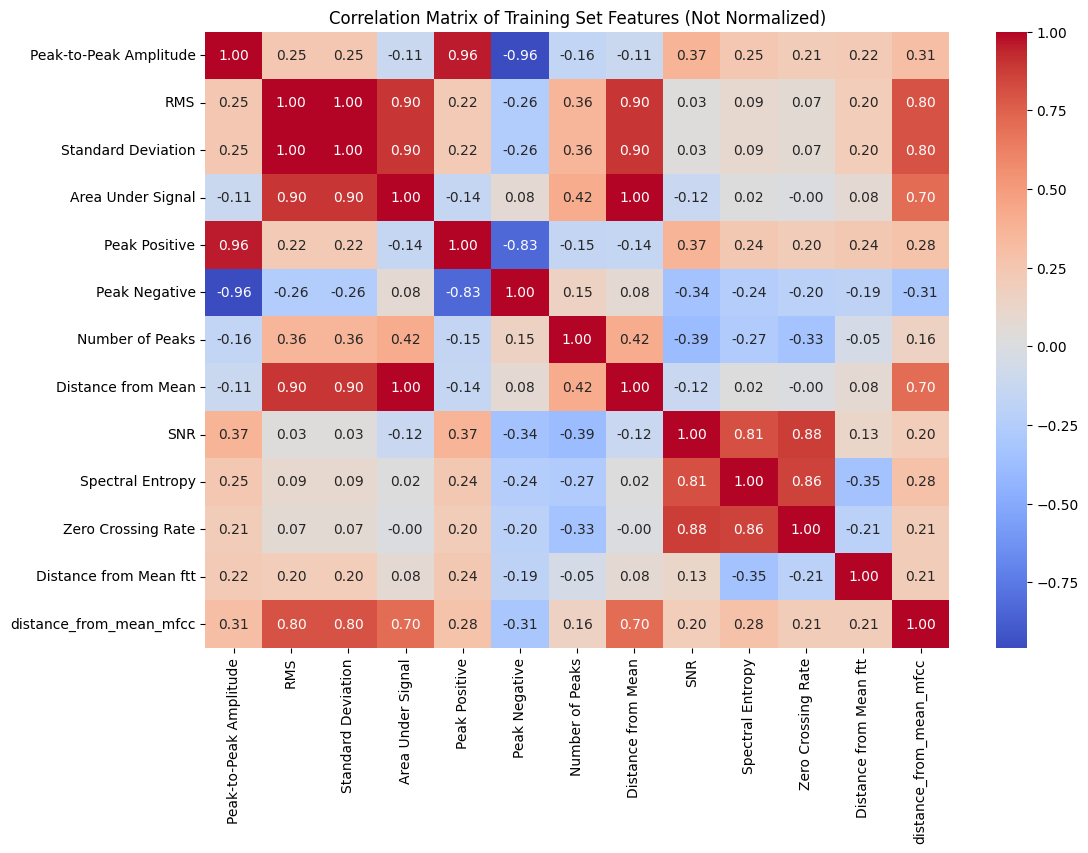

In [ ]:
# Compute the correlation matrix
correlation_matrix = features_df.corr()

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix of Training Set Features (Not Normalized)")
plt.show()

In [ ]:
from sklearn.decomposition import PCA

# Apply PCA to normalized features
pca = PCA(n_components=0.70)  # Retain 90% of variance
pca.fit(normalized_features)

# Print the number of components
print(f"Number of components to retain 90% variance: {pca.n_components_}")

Number of components to retain 90% variance: 3


In [ ]:
# Apply PCA to the normalized features
pca = PCA(n_components=0.60)  # Retain 90% of variance
pca_features = pca.fit_transform(normalized_features)

# Train the One-Class SVM model on PCA-transformed features
oc_svm_pca = OneClassSVM(kernel='rbf', gamma=0.1, nu=0.1)
oc_svm_pca.fit(pca_features)

# Train the Isolation Forest model on PCA-transformed features
iso_forest_pca = IsolationForest(contamination=0.1, random_state=42, n_estimators=200)
iso_forest_pca.fit(pca_features)



IsolationForest(contamination=0.1, n_estimators=200, random_state=42)

In [ ]:
from sklearn.metrics import roc_auc_score
# Apply PCA transformation on the normalized test features
test_pca_features = pca.transform(test_features_df_normalized)
# Predict anomaly scores using the Isolation Forest model trained on PCA-transformed features
anomaly_scores_pca = iso_forest_pca.decision_function(test_pca_features)
print(anomaly_scores_pca.shape)
y_test = [1 if audio_file.startswith("normal") else -1 for audio_file in os.listdir(test_dir) if audio_file.endswith(".wav")]
print(len(y_test))
# Evaluate using Area Under the Curve (AUC)
auc_score_pca = roc_auc_score(y_test, anomaly_scores_pca)
print(f"Area Under Curve (AUC) Score Isolation Forest with PCA: {auc_score_pca}")

# Predict anomaly scores using the One-Class SVM model trained on PCA-transformed features
oc_svm_scores_pca = oc_svm_pca.decision_function(test_pca_features)

# Evaluate using Area Under the Curve (AUC)
auc_score_oc_svm_pca = roc_auc_score(y_test, oc_svm_scores_pca)
print(f"Area Under Curve (AUC) Score One-Class SVM with PCA: {auc_score_oc_svm_pca}")

(1101,)
1101
Area Under Curve (AUC) Score Isolation Forest with PCA: 0.8107490636704119
Area Under Curve (AUC) Score One-Class SVM with PCA: 0.8340366208905535


In [ ]:
# Calculate the correlation matrix
correlation_matrix = features_df.corr()

# Identify features with high correlation 
high_corr_pairs = set()
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > 0.30: # change this value
            high_corr_pairs.add(correlation_matrix.columns[i])

# Drop highly correlated features
reduced_features_df = features_df.drop(columns=high_corr_pairs)
print(f"Reduced features: {reduced_features_df.columns.tolist()}")

# Normalize the reduced features
scaler = StandardScaler()
normalized_reduced_features = scaler.fit_transform(reduced_features_df)

# Reapply Isolation Forest
iso_forest_reduced = IsolationForest(contamination=0.1, random_state=42, n_estimators=200)
iso_forest_reduced.fit(reduced_features_df)
anomaly_scores_reduced = iso_forest_reduced.decision_function(reduced_features_df)

# Reapply One-Class SVM
oc_svm_reduced = OneClassSVM(kernel='rbf', gamma=0.1, nu=0.1)
oc_svm_reduced.fit(normalized_reduced_features)

# Evaluate models on the test set
test_reduced_features_df = test_features_df[reduced_features_df.columns]
test_reduced_features_normalized = scaler.transform(test_reduced_features_df)

# Isolation Forest evaluatio
test_anomaly_scores_reduced = iso_forest_reduced.decision_function(test_reduced_features_df)
auc_score_iso_forest_reduced = roc_auc_score(y_test, test_anomaly_scores_reduced)
print(f"Isolation Forest AUC (Reduced Features): {auc_score_iso_forest_reduced}")

# One-Class SVM evaluation
test_oc_svm_scores_reduced = oc_svm_reduced.decision_function(test_reduced_features_normalized)
auc_score_oc_svm_reduced = roc_auc_score(y_test, test_oc_svm_scores_reduced)
print(f"One-Class SVM AUC (Reduced Features): {auc_score_oc_svm_reduced}")

Reduced features: ['Peak-to-Peak Amplitude', 'RMS']
Isolation Forest AUC (Reduced Features): 0.9161215147732
One-Class SVM AUC (Reduced Features): 0.8913441531419058


In [ ]:
from collections import defaultdict

# Dictionary to store means for each machine ID
audio_dir = "archive/eval_data/eval_data/slider/train"
machine_means = defaultdict(list)

# Iterate through audio files in the train set
for audio_file in os.listdir(audio_dir):
    if audio_file.endswith(".wav"):
        # Extract machine ID from the file name (assuming the format includes "_id_XX_")
        machine_id = audio_file.split("_id_")[1].split("_")[0]
        
        # Load the audio file
        audio_path = os.path.join(audio_dir, audio_file)
        y, sr = librosa.load(audio_path, sr=None)
        
        # Compute the mean of the audio signal
        mean_value = np.mean(y)
        
        # Append the mean to the corresponding machine ID
        machine_means[machine_id].append(mean_value)

# Compute the overall mean for each machine ID
machine_means = {machine_id: np.mean(means) for machine_id, means in machine_means.items()}

print(machine_means)

# Dictionary to store FFT means for each machine ID
machine_fft_means = defaultdict(list)

# Iterate through audio files in the train set
for audio_file in os.listdir(audio_dir):
    if audio_file.endswith(".wav"):
        # Extract machine ID from the file name
        machine_id = audio_file.split("_id_")[1].split("_")[0]
        
        # Load the audio file
        audio_path = os.path.join(audio_dir, audio_file)
        y, sr = librosa.load(audio_path, sr=None)
        
        # Compute the FFT of the audio signal
        fft = np.fft.fft(y)
        magnitude = np.abs(fft)
        
        # Compute the mean of the FFT magnitude
        fft_mean = np.mean(magnitude)
        
        # Append the FFT mean to the corresponding machine ID
        machine_fft_means[machine_id].append(fft_mean)

# Compute the overall FFT mean for each machine ID
machine_fft_means = {machine_id: np.mean(means) for machine_id, means in machine_fft_means.items()}

print(machine_fft_means)

{'01': np.float32(-3.1272756e-07), '03': np.float32(-5.5603556e-07), '05': np.float32(-4.0982022e-07)}
{'01': np.float32(1.8997977), '03': np.float32(1.9635754), '05': np.float32(2.299501)}


In [ ]:
# Define the new audio directory
new_audio_dir = "archive/eval_data/eval_data/slider/train"

# Initialize a list to store features
new_features = []

# Iterate through audio files in the new directory
for audio_file in os.listdir(new_audio_dir):
    if audio_file.endswith(".wav"):
        machine_id = audio_file.split("_id_")[1].split("_")[0]
        audio_path = os.path.join(new_audio_dir, audio_file)
        y, sr = librosa.load(audio_path, sr=None)
        peak_to_peak_amplitude = np.ptp(y)
        rms = np.sqrt(np.mean(y**2))
        std_dev = np.std(y)
        area_under_signal = np.sum(np.abs(y)) / sr
        peak_positive = np.max(y)
        peak_negative = np.min(y)
        fft_magnitude = np.abs(np.fft.rfft(y))
        num_peaks, _ = find_peaks(fft_magnitude, height=250)
        distance_from_mean = np.mean(np.abs(y - machine_means[machine_id]))
        distance_from_mean_fft = np.mean(np.abs(fft_magnitude - machine_fft_means[machine_id]))
        snr = np.mean(fft_magnitude) / np.std(fft_magnitude)
        spectral_entropy = entropy(fft_magnitude / np.sum(fft_magnitude))
        zcr = np.mean(librosa.feature.zero_crossing_rate(y))
        new_features.append({
            "Peak-to-Peak Amplitude": peak_to_peak_amplitude,
            "RMS": rms
        })

# Create a DataFrame for the new features
new_features_df = pd.DataFrame(new_features)
print(new_features_df)

      Peak-to-Peak Amplitude       RMS
0                   0.117493  0.012080
1                   0.107880  0.012065
2                   0.094269  0.010243
3                   0.090942  0.010228
4                   0.120880  0.012126
...                      ...       ...
2365                0.157593  0.010903
2366                0.115082  0.011268
2367                0.120026  0.011401
2368                0.095306  0.010997
2369                0.103180  0.011154

[2370 rows x 2 columns]


In [ ]:
new_features_df.to_csv("new_training_set_reduced.csv", index=False)

In [ ]:
# Calculate the correlation matrix
correlation_matrix = new_features_df.corr()

# Identify features with high correlation 
high_corr_pairs = set()
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > 0.40: # change this value
            high_corr_pairs.add(correlation_matrix.columns[i])

# Drop highly correlated features
reduced_features_df = new_features_df.drop(columns=high_corr_pairs)
print(f"Reduced features: {reduced_features_df.columns.tolist()}")

# Normalize the reduced features
scaler = StandardScaler()
normalized_reduced_features = scaler.fit_transform(reduced_features_df)

# Reapply Isolation Forest
iso_forest_reduced = IsolationForest(contamination=0.1, random_state=42, n_estimators=200)
iso_forest_reduced.fit(reduced_features_df)
anomaly_scores_reduced = iso_forest_reduced.decision_function(reduced_features_df)

# Reapply One-Class SVM
oc_svm_reduced = OneClassSVM(kernel='rbf', gamma=0.1, nu=0.1)
oc_svm_reduced.fit(normalized_reduced_features)

# Evaluate models on the test set
test_reduced_features_df = test_features_df[reduced_features_df.columns]
test_reduced_features_normalized = scaler.transform(test_reduced_features_df)

# Isolation Forest evaluatio
test_anomaly_scores_reduced = iso_forest_reduced.decision_function(test_reduced_features_df)
auc_score_iso_forest_reduced = roc_auc_score(y_test, test_anomaly_scores_reduced)
print(f"Isolation Forest AUC (Reduced Features): {auc_score_iso_forest_reduced}")

# One-Class SVM evaluation
test_oc_svm_scores_reduced = oc_svm_reduced.decision_function(test_reduced_features_normalized)
auc_score_oc_svm_reduced = roc_auc_score(y_test, test_oc_svm_scores_reduced)
print(f"One-Class SVM AUC (Reduced Features): {auc_score_oc_svm_reduced}")

Reduced features: ['Peak-to-Peak Amplitude', 'RMS']
Isolation Forest AUC (Reduced Features): 0.766608406158968
One-Class SVM AUC (Reduced Features): 0.7867540574282147
